In [ ]:
# Load the dataset
from google.colab import files
uploaded = files.upload()
# Function to load CSV file using Pandas
import pandas as pd
dataset = pd.read_csv('unclean_crm_dataset_.csv')
dataset.head()

Saving unclean_crm_dataset_.csv to unclean_crm_dataset_ (2).csv


,Lead_ID,Customer_Name,Email,Phone,Lead_Source,Industry,City,Sales_Stage,Created_Date,Close_Date,Deal_Value,Sales_Rep,Last_Contacted,Churn_Flag
0,NaN,NaN,user0@example,NaN,Referral,Real Estate,bangalore,WON,13-07-2022,16-03-2023,557597,AMIT,18-10-2022,NaN
1,1,NaN,user1example.com,7.729251e+09,Referral,Manufacturing,DELHI,Contacted,04-01-2020,04-26-2020,unknown,Priya,22-12-2020,no
2,L2,NaN,user2@example.com,3.980060e+06,coldcall,Real Estate,Delhi,Lost,13-06-2019,NaN,39862,Rahul,18-02-2019,no
3,NaN,NaN,user3@example.com,8.750642e+09,Email Campaign,Manufacturing,Mumbai,New,11-07-2019,08-22-2019,NaN,Sneha,04-05-2020,No
4,L4,NaN,user4@example,9.969125e+09,Cold Call,Manufacturing,Bengaluru,NaN,02-05-2019,NaN,NaN,Amit,19-02-2019,N


In [ ]:
# Basic Data Profiling
# Dataset Shape
print(f"Dataset Shape: {dataset.shape}")

# Column Names
print(f"\nColumn Names: {', '.join(dataset.columns)}")

# Data Types
print("\nData Types:")
print(dataset.dtypes)

# Dataset Info
print("\nDataset Info:")
dataset.info()

# Statistical Summary
print("\nStatistical Summary:")
print(dataset.describe())
print(dataset.describe(include='all'))

# Duplicate Rows
print(f"\nNumber of Duplicate Rows: {dataset.duplicated().sum()}")

Dataset Shape: (100000, 14)

Column Names: Lead_ID, Customer_Name, Email, Phone, Lead_Source, Industry, City, Sales_Stage, Created_Date, Close_Date, Deal_Value, Sales_Rep, Last_Contacted, Churn_Flag

Data Types:
Lead_ID            object
Customer_Name      object
Email              object
Phone             float64
Lead_Source        object
Industry           object
City               object
Sales_Stage        object
Created_Date       object
Close_Date         object
Deal_Value         object
Sales_Rep          object
Last_Contacted     object
Churn_Flag         object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Lead_ID         59756 non-null   object 
 1   Customer_Name   50000 non-null   object 
 2   Email           89965 non-null   object 
 3   Phone           87525 non-null   float64
 4   Lead

In [ ]:
# Advanced Data Profiling Before Schema Fixes
# Unique Values Analysis
print(f"Unique Value Analysis Before Schema Fixes:")
print(dataset.nunique())

# Value Distribution for Categorical Columns
print("\nValue Distribution for Categorical Columns Before Schema Fixes:")
for col in dataset.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(dataset[col].value_counts())

# Numerical Column Distribution
print("\nNumerical Column Distribution Before Schema Fixes:")
print(dataset.select_dtypes(include=['int64', 'float64']).describe().T)

Unique Value Analysis Before Schema Fixes:
Lead_ID           59756
Customer_Name     50000
Email             89965
Phone             87324
Lead_Source           9
Industry             10
City                 10
Sales_Stage          10
Created_Date       4028
Close_Date         4554
Deal_Value        24248
Sales_Rep             7
Last_Contacted     2997
Churn_Flag            6
dtype: int64

Value Distribution for Categorical Columns Before Schema Fixes:

Column: Lead_ID
Lead_ID
99996      1
1          1
L2         1
L4         1
LEAD-5     1
          ..
LEAD-25    1
LEAD-22    1
21         1
LEAD-19    1
18         1
Name: count, Length: 59756, dtype: int64

Column: Customer_Name
Customer_Name
Customer 99975    1
Customer 99974    1
Cust-99973        1
Customer 99972    1
Customer 99971    1
                 ..
Cust-17           1
Cust-16           1
Customer 15       1
Cust-14           1
Cust-10           1
Name: count, Length: 50000, dtype: int64

Column: Email
Email
user99999@examp

In [ ]:
# Basic Schema Fixes
# Clean column names
dataset.columns = dataset.columns.str.replace('_', ' ')
print(f"Cleaned Column Names: {", ".join(dataset.columns)}")

# Convert date format
import pandas as pd
import re
def clean_and_convert(date_value):
    if pd.isna(date_value):
        return pd.NaT
    # Convert to string
    x = str(date_value)
    # Remove ALL non-visible characters
    x = re.sub(r'[^\x00-\x7F]+', '', x)
    # Remove spaces
    x = x.strip()
    # Replace any weird dash with normal dash
    x = x.replace('–', '-').replace('—', '-')
    # Keep only numbers and dash
    x = re.sub(r'[^0-9\-]', '', x)
    if x == '':
        return pd.NaT
    parts = x.split('-')
    if len(parts) != 3:
        return pd.NaT
    first = int(parts[0])
    second = int(parts[1])
    try:
        # If second > 12 → MM-DD-YYYY
        if second > 12:
            return pd.to_datetime(x, format='%m-%d-%Y')
        else:
            return pd.to_datetime(x, format='%d-%m-%Y')
    except:
        return pd.NaT
for col in ['Close Date','Created Date','Last Contacted']:
    dataset[col] = dataset[col].apply(clean_and_convert)
# Final display format
for col in ['Close Date','Created Date','Last Contacted']:
    dataset[col] = dataset[col].dt.strftime('%d-%m-%Y')
print("\nCleaned Date Format:")
print(dataset[['Close Date','Created Date','Last Contacted']])

# Convert numeric columns
print("\nCleaned Data Type:")
dataset['Deal Value'] = pd.to_numeric(dataset['Deal Value'], errors='coerce')
dataset.dtypes

Cleaned Column Names: Lead ID, Customer Name, Email, Phone, Lead Source, Industry, City, Sales Stage, Created Date, Close Date, Deal Value, Sales Rep, Last Contacted, Churn Flag

Cleaned Date Format:
       Close Date Created Date Last Contacted
0      16-03-2023   13-07-2022     18-10-2022
1      26-04-2020   04-01-2020     22-12-2020
2             NaN   13-06-2019     18-02-2019
3      22-08-2019   11-07-2019     04-05-2020
4             NaN   02-05-2019     19-02-2019
...           ...          ...            ...
99995  01-12-2019   27-01-2020     26-12-2020
99996  14-08-2020   29-05-2020     17-04-2021
99997  15-05-2019   20-10-2018     29-05-2019
99998  17-08-2020   20-12-2019     28-08-2019
99999  16-08-2021   09-01-2021     09-07-2021

[100000 rows x 3 columns]

Cleaned Data Type:


,0
Lead ID,object
Customer Name,object
Email,object
Phone,float64
Lead Source,object
Industry,object
City,object
Sales Stage,object
Created Date,object
Close Date,object


In [ ]:
# Advanced Schema Fixes
# Standardize Text Columns
# Remove extra space from text columns
text_cols = dataset.select_dtypes(include='object').columns
for col in text_cols:
    dataset[col] = dataset[col].str.strip()

# Remove special characters and multiple spaces
for col in text_cols:
    dataset[col] = dataset[col].apply(
        lambda x: re.sub(r'\s+', ' ', x) if pd.notnull(x) else x
    )

# Convert columns to Title Case
for col in text_cols:
    dataset[col] = dataset[col].str.title()

# Normalize Common word pattern (Generic Rule)
# Remove spaces between words like "Web Site" → "Website"
dataset['Lead Source'] = dataset['Lead Source'].str.replace(
    r'\bWeb\s+Site\b', 'Website', regex=True
)
# Normalize common short forms automatically
dataset['Industry'] = dataset['Industry'].replace(
    dataset['Industry'].str.extract(r'^(Edu).*', expand=False).dropna().unique(),
    'Education'
)
# Lead Source fixes (Cold Call variations)
dataset['Lead Source'] = dataset['Lead Source'].replace({
    'Coldcall': 'Cold Call'
})
# City standardization (Bangalore → Bengaluru, DELHI → Delhi)
dataset['City'] = dataset['City'].replace({
    'Bangalore': 'Bengaluru',
    'Delhi': 'Delhi'
})
# Sales Stage (WON, won → Won)
dataset['Sales Stage'] = dataset['Sales Stage'].str.title()
# If special variations exist
dataset['Sales Stage'] = dataset['Sales Stage'].replace({
    'Closed-Won': 'Closed Won',
    'Closedwon': 'Closed Won'
})
# Sales Rep (AMIT, rahul → Amit, Rahul)
dataset['Sales Rep'] = dataset['Sales Rep'].str.title()
# Fix Churn Fix
dataset['Churn Flag'] = dataset['Churn Flag'].str.lower()
dataset['Churn Flag'] = dataset['Churn Flag'].apply(
    lambda x: 'Yes' if x in ['yes', 'y']
    else ('No' if x in ['no', 'n']
    else x)
)
dataset.head(30)

,Lead ID,Customer Name,Email,Phone,Lead Source,Industry,City,Sales Stage,Created Date,Close Date,Deal Value,Sales Rep,Last Contacted,Churn Flag
0,NaN,NaN,User0@Example,NaN,Referral,Real Estate,Bengaluru,Won,13-07-2022,16-03-2023,557597.0,Amit,18-10-2022,NaN
1,1,NaN,User1Example.Com,7.729251e+09,Referral,Manufacturing,Delhi,Contacted,04-01-2020,26-04-2020,NaN,Priya,22-12-2020,No
2,L2,NaN,User2@Example.Com,3.980060e+06,Cold Call,Real Estate,Delhi,Lost,13-06-2019,NaN,39862.0,Rahul,18-02-2019,No
3,NaN,NaN,User3@Example.Com,8.750642e+09,Email Campaign,Manufacturing,Mumbai,New,11-07-2019,22-08-2019,NaN,Sneha,04-05-2020,No
4,L4,NaN,User4@Example,9.969125e+09,Cold Call,Manufacturing,Bengaluru,NaN,02-05-2019,NaN,NaN,Amit,19-02-2019,No
5,Lead-5,NaN,User5@Example.Com,8.295093e+09,NaN,Finance,Hyderabad,NaN,25-03-2022,16-08-2022,98165.0,Rahul,13-03-2022,No
6,Lead-6,NaN,User6@Example.Com,NaN,NaN,Education,Hyderabad,Lost,19-10-2020,01-04-2021,NaN,Sneha,06-04-2021,NaN
7,Lead-7,NaN,User7@Example.Com,8.982157e+09,Referral,Real Estate,Pune,NaN,07-03-2020,17-04-2020,-2083.0,Rohit,04-04-2021,Yes
8,Lead-8,NaN,User8@Example.Com,8.195226e+09,NaN,Healthcare,Delhi,NaN,11-09-2023,19-08-2024,-4138.0,Amit,27-10-2023,No
9,9,NaN,NaN,8.393279e+09,Walk-In,Education,Hyderabad,Won,07-05-2024,NaN,-2918.0,Sneha,07-06-2025,NaN



Top Values per Column Before Handling Values:
               Data Type  Unique Values  Null Count  Null %
Lead ID           object          59756       40244  40.244
Customer Name     object          50000       50000  50.000
Email             object          89965       10035  10.035
Phone            float64          87324       12475  12.475
Lead Source       object              7       18123  18.123
Industry          object              7        9182   9.182
City              object              7        9108   9.108
Sales Stage       object              7        8956   8.956
Created Date      object           2516           0   0.000
Close Date        object           2874       25057  25.057
Deal Value       float64          24247       60134  60.134
Sales Rep         object              5       22270  22.270
Last Contacted    object           2997           0   0.000
Churn Flag        object              2       24819  24.819


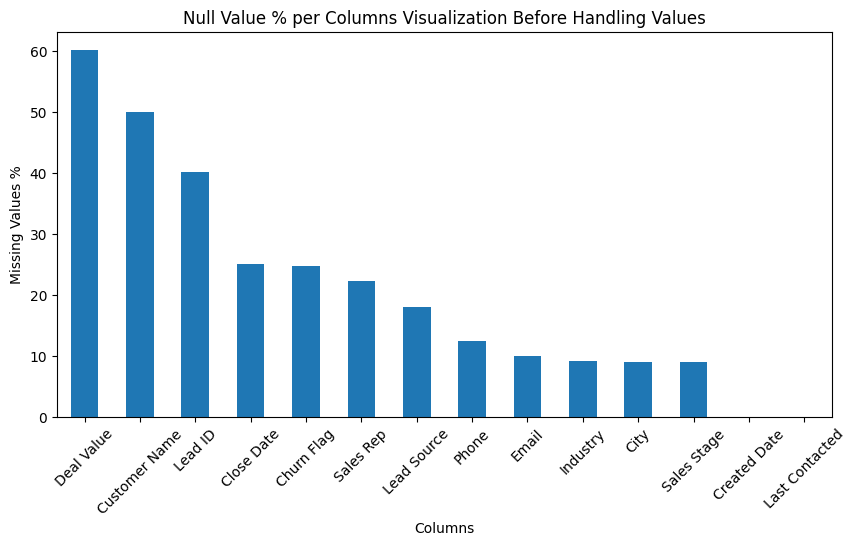

In [ ]:
# Basic Null Value Analysis Before Handling Values
# Top Values per Column (Quick Profile Table)
print("\nTop Values per Column Before Handling Values:")
profile = pd.DataFrame({
    'Data Type': dataset.dtypes,
    'Unique Values': dataset.nunique(),
    'Null Count': dataset.isnull().sum(),
    'Null %': (dataset.isnull().sum()/len(dataset))*100
})
print(profile)

# Single Visualization for Profiling
import matplotlib.pyplot as plt
null_percentage = (dataset.isnull().sum() / len(dataset)) * 100      # Calculate null percentage
plt.figure(figsize=(10,5))                                           # Set figure size
null_percentage.sort_values(ascending=False).plot(kind='bar')
plt.title("Null Value % per Columns Visualization Before Handling Values")
plt.ylabel("Missing Values %")
plt.xlabel("Columns")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Advanced Null Value Analysis
# Identify columns with high null values
print("\nHigh Null Values(< 30) Columns:")
high_null_cols = null_percentage[null_percentage > 30]
print(high_null_cols)

# Overall Missing Data Summary
total_nulls = dataset.isnull().sum().sum()
total_cells = dataset.shape[0] * dataset.shape[1]
null_ratio = (total_nulls / total_cells) * 100
print("\nTotal Missing Values in Dataset:", total_nulls)
print("Overall Missing Data Percentage:", round(null_ratio,2), "%")

# Rows Containing Missing Values
rows_with_null = dataset.isnull().any(axis=1).sum()
print("\nNumber of Rows Containing Null Values:", rows_with_null)
print("Percentage of Rows Affected:",
      round((rows_with_null/len(dataset))*100,2), "%")

# Columns Fully Empty
empty_columns = dataset.columns[dataset.isnull().all()]
print("\nFully Empty Columns:", list(empty_columns))

# Null Distribution by Data Type
null_by_dtype = dataset.isnull().sum().groupby(dataset.dtypes).sum()
print("\nNull Values Grouped by Data Type:")
print(null_by_dtype)

# Null Pattern Check (Logical Insight)
null_close_stage = dataset[
    (dataset['Close Date'].isnull()) &
    (dataset['Sales Stage'] == 'Closed Won')
]
print("\nClosed Won Deals without Close Date:", len(null_close_stage))


High Null Values(< 30) Columns:
Lead ID          40.244
Customer Name    50.000
Deal Value       60.134
dtype: float64

Total Missing Values in Dataset: 290403
Overall Missing Data Percentage: 20.74 %

Number of Rows Containing Null Values: 97470
Percentage of Rows Affected: 97.47 %

Fully Empty Columns: []

Null Values Grouped by Data Type:
float64     72609
object     217794
dtype: int64

Closed Won Deals without Close Date: 0


In [ ]:
# Handle Null Values (Basic Cleaning)
# Basic Handling Mixed Lead IDs
# Keep original copy
dataset['Original Lead ID'] = dataset['Lead ID']
# Convert to numeric (Standardize)
dataset['Lead ID Numeric'] = pd.to_numeric(dataset['Lead ID'], errors='coerce')
print("Lead IDs Conversion:")
print(dataset[['Original Lead ID', 'Lead ID Numeric']])

total_rows = len(dataset)

# Check Missing Lead IDs
missing_ids = dataset['Lead ID'].isnull().sum()
print("\nMissing Lead IDs:", missing_ids)
missing_pct = (dataset['Lead ID Numeric'].isnull().sum() / total_rows) * 100
print("Missing Lead ID %:", round(missing_pct,2), "%")

# Check Duplicate Lead IDs
duplicate_ids = dataset['Lead ID'].duplicated().sum()
print("\nDuplicate Lead IDs:", duplicate_ids)
duplicate_pct = (dataset['Lead ID Numeric'].duplicated().sum() / total_rows) * 100
print("Duplicate Lead ID %:", round(duplicate_pct,2), "%")

# Identify Non-Numeric IDs
non_numeric_ids = dataset[
    dataset['Lead ID'].notnull() &
    dataset['Lead ID Numeric'].isnull()
]
print("\nNon-Numeric Lead IDs:")
print(non_numeric_ids['Lead ID'].unique())

# Check Negative or Zero IDs
invalid_numeric_ids = dataset[
    (dataset['Lead ID Numeric'] <= 0)
]
print("\nInvalid Numeric IDs (<=0):", len(invalid_numeric_ids))

# Count of Valid and Invalid Lead IDs
total_rows = len(dataset)
# Valid Lead IDs
valid_ids = dataset[
    dataset['Lead ID Numeric'].notnull() &
    (dataset['Lead ID Numeric'] > 0)
]
valid_count = len(valid_ids)
print("\nValid Lead IDs:", valid_count)
print("Valid Lead ID %:", round((valid_count/total_rows)*100,2), "%")
# Invalid Lead IDs
invalid_ids = dataset[
    dataset['Lead ID Numeric'].isnull() |
    (dataset['Lead ID Numeric'] <= 0)
]
invalid_count = len(invalid_ids)
print("\nInvalid Lead IDs:", invalid_count)
print("Invalid Lead ID %:", round((invalid_count/total_rows)*100,2), "%")


Lead IDs Conversion:
      Original Lead ID  Lead ID Numeric
0                  NaN              NaN
1                    1              1.0
2                   L2              NaN
3                  NaN              NaN
4                   L4              NaN
...                ...              ...
99995              NaN              NaN
99996            99996          99996.0
99997              NaN              NaN
99998              NaN              NaN
99999              NaN              NaN

[100000 rows x 2 columns]

Missing Lead IDs: 40244
Missing Lead ID %: 80.04 %

Duplicate Lead IDs: 40243
Duplicate Lead ID %: 80.03 %

Non-Numeric Lead IDs:
['L2' 'L4' 'Lead-5' ... 'L99989' 'Lead-99991' 'L99994']

Invalid Numeric IDs (<=0): 0

Valid Lead IDs: 19965
Valid Lead ID %: 19.96 %

Invalid Lead IDs: 80035
Invalid Lead ID %: 80.03 %


In [ ]:
# Advanced Handling Mixed Lead IDs
# Create New Unique ID
dataset['New Lead ID'] = range(1, len(dataset)+1)
print("New Lead IDs:")
print(dataset['New Lead ID'])

dataset['Lead ID Cleaned'] = dataset['Lead ID Numeric']

# Replace only missing or duplicate IDs
mask = (
    dataset['Lead ID Cleaned'].isnull() |
    dataset['Lead ID Cleaned'].duplicated()
)
# Get the current maximum value and convert to integer
current_max_id = dataset['Lead ID Cleaned'].max()
# Handle the case where max() might return NaN if all values are NaN
if pd.isna(current_max_id):
    start_new_ids = 1
else:
    start_new_ids = int(current_max_id) + 1

dataset.loc[mask, 'Lead ID Cleaned'] = range(
    start_new_ids,
    start_new_ids + mask.sum()
)
print("\nAfter Replacement Lead IDs:")
print(dataset[['New Lead ID', 'Lead ID Cleaned']])

# Total Lead IDs After Cleaning
missing_after = dataset['Lead ID Cleaned'].isnull().sum()
duplicates_after = dataset['Lead ID Cleaned'].duplicated().sum()
invalid_after = (dataset['Lead ID Cleaned'] <= 0).sum()
print("\nMissing Lead IDs:", missing_after)
print("Duplicate Lead IDs:", duplicates_after)
print("Invalid Lead IDs (<=0):", invalid_after)

New Lead IDs:
0             1
1             2
2             3
3             4
4             5
          ...  
99995     99996
99996     99997
99997     99998
99998     99999
99999    100000
Name: New Lead ID, Length: 100000, dtype: int64

After Replacement Lead IDs:
       New Lead ID  Lead ID Cleaned
0                1          99997.0
1                2              1.0
2                3          99998.0
3                4          99999.0
4                5         100000.0
...            ...              ...
99995        99996         180028.0
99996        99997          99996.0
99997        99998         180029.0
99998        99999         180030.0
99999       100000         180031.0

[100000 rows x 2 columns]

Missing Lead IDs: 0
Duplicate Lead IDs: 0
Invalid Lead IDs (<=0): 0


In [ ]:
# Handling Emails
# Keep original email
dataset['Original Email'] = dataset['Email']
# Standardize Email Case
dataset['Email Cleaned'] = dataset['Email'].str.lower().str.strip()
print("After Standardizing Email:")
print(dataset[['Original Email', 'Email Cleaned']])

# Replace Empty Strings with NaN
dataset['Email Cleaned'] = dataset['Email Cleaned'].replace('', pd.NA)
print("\nAfter Replacing Empty Strings with NA:")
print(dataset['Email Cleaned'].head(30))

# Basic Email Validation
import re
def is_valid_email(email):
    if pd.isnull(email):
        return False
    pattern = r'^[\w\.-]+@[\w\.-]+\.\w+$'
    return re.match(pattern, str(email)) is not None
dataset['Valid Email'] = dataset['Email Cleaned'].apply(is_valid_email)
print("\nValidation Column Added:")
print(dataset[['Email Cleaned','Valid Email']])

# Count Valid & Invalid Emails
valid_count = dataset['Valid Email'].sum()
invalid_count = len(dataset) - valid_count
print("\nValid Emails:", valid_count)
print("Invalid Emails:", invalid_count)

# Show Invalid Email Records
invalid_emails = dataset[dataset['Valid Email'] == False]
print("\nInvalid Email Records Sample:")
print(invalid_emails[['Email Cleaned']])

# Handle Invalid Emails
dataset.loc[dataset['Valid Email'] == False, 'Email Cleaned'] = pd.NA
print("\nAfter Removing Invalid Emails:")
print(dataset['Email Cleaned'])

# Total Missing Email Before and After Cleaning
print("\nTotal Missing Emails Before Cleaning:", dataset['Email'].isna().sum())
print("Total Missing Emails After Cleaning:", (dataset['Valid Email'] == False).sum())

After Standardizing Email:
              Original Email          Email Cleaned
0              User0@Example          user0@example
1           User1Example.Com       user1example.com
2          User2@Example.Com      user2@example.com
3          User3@Example.Com      user3@example.com
4              User4@Example          user4@example
...                      ...                    ...
99995  User99995@Example.Com  user99995@example.com
99996  User99996@Example.Com  user99996@example.com
99997  User99997@Example.Com  user99997@example.com
99998  User99998@Example.Com  user99998@example.com
99999  User99999@Example.Com  user99999@example.com

[100000 rows x 2 columns]

After Replacing Empty Strings with NA:
0          user0@example
1       user1example.com
2      user2@example.com
3      user3@example.com
4          user4@example
5      user5@example.com
6      user6@example.com
7      user7@example.com
8      user8@example.com
9                    NaN
10    user10@example.com
11    u

In [ ]:
dataset.head(50)

,Lead ID,Customer Name,Email,Phone,Lead Source,Industry,City,Sales Stage,Created Date,Close Date,...,Sales Rep,Last Contacted,Churn Flag,Original Lead ID,Lead ID Numeric,New Lead ID,Lead ID Cleaned,Original Email,Email Cleaned,Valid Email
0,NaN,NaN,User0@Example,NaN,Referral,Real Estate,Bengaluru,Won,13-07-2022,16-03-2023,...,Amit,18-10-2022,NaN,NaN,NaN,1,99997.0,User0@Example,<NA>,False
1,1,NaN,User1Example.Com,7.729251e+09,Referral,Manufacturing,Delhi,Contacted,04-01-2020,26-04-2020,...,Priya,22-12-2020,No,1,1.0,2,1.0,User1Example.Com,<NA>,False
2,L2,NaN,User2@Example.Com,3.980060e+06,Cold Call,Real Estate,Delhi,Lost,13-06-2019,NaN,...,Rahul,18-02-2019,No,L2,NaN,3,99998.0,User2@Example.Com,user2@example.com,True
3,NaN,NaN,User3@Example.Com,8.750642e+09,Email Campaign,Manufacturing,Mumbai,New,11-07-2019,22-08-2019,...,Sneha,04-05-2020,No,NaN,NaN,4,99999.0,User3@Example.Com,user3@example.com,True
4,L4,NaN,User4@Example,9.969125e+09,Cold Call,Manufacturing,Bengaluru,NaN,02-05-2019,NaN,...,Amit,19-02-2019,No,L4,NaN,5,100000.0,User4@Example,<NA>,False
5,Lead-5,NaN,User5@Example.Com,8.295093e+09,NaN,Finance,Hyderabad,NaN,25-03-2022,16-08-2022,...,Rahul,13-03-2022,No,Lead-5,NaN,6,100001.0,User5@Example.Com,user5@example.com,True
6,Lead-6,NaN,User6@Example.Com,NaN,NaN,Education,Hyderabad,Lost,19-10-2020,01-04-2021,...,Sneha,06-04-2021,NaN,Lead-6,NaN,7,100002.0,User6@Example.Com,user6@example.com,True
7,Lead-7,NaN,User7@Example.Com,8.982157e+09,Referral,Real Estate,Pune,NaN,07-03-2020,17-04-2020,...,Rohit,04-04-2021,Yes,Lead-7,NaN,8,100003.0,User7@Example.Com,user7@example.com,True
8,Lead-8,NaN,User8@Example.Com,8.195226e+09,NaN,Healthcare,Delhi,NaN,11-09-2023,19-08-2024,...,Amit,27-10-2023,No,Lead-8,NaN,9,100004.0,User8@Example.Com,user8@example.com,True
9,9,NaN,NaN,8.393279e+09,Walk-In,Education,Hyderabad,Won,07-05-2024,NaN,...,Sneha,07-06-2025,NaN,9,9.0,10,9.0,NaN,<NA>,False


In [ ]:
# Handling Phone Numbers
# Keep Original Phone
dataset['Original Phone'] = dataset['Phone']
# Convert float numbers safely (remove .0 properly)
dataset['Phone Cleaned'] = (
    dataset['Phone']
    .apply(lambda x: str(int(x)) if pd.notnull(x) and str(x).endswith('.0') else str(x))
)
print("After Converting Float Numbers:")
print(dataset['Phone Cleaned'])

# Remove Spaces and Special Characters
dataset['Phone Cleaned'] = dataset['Phone Cleaned'].astype(str).str.replace(r'\D', '', regex=True)
print("\nAfter Removing Spaces and Special Characters:")
print(dataset[['Original Phone','Phone Cleaned']])

# Replace Empty Strings with NaN
dataset['Phone Cleaned'] = dataset['Phone Cleaned'].replace('', pd.NA)
print("\nAfter Replacing Empty Strings with NA:")
print(dataset['Phone Cleaned'].head(20))

# Validate Phone Length (10 digits only)
dataset['Valid Phone'] = dataset['Phone Cleaned'].apply(
    lambda x: True if pd.notnull(x) and len(x) == 10 else False
)
print("\nValidation Column Added:")
print(dataset[['Phone Cleaned','Valid Phone']])

# Count Valid & Invalid Emails
valid_count = dataset['Valid Phone'].sum()
invalid_count = len(dataset) - valid_count
print("\nValid Phone:", valid_count)
print("Invalid Phone:", invalid_count)

# Handle Invalid Phones
dataset.loc[dataset['Valid Phone'] == False, 'Phone Cleaned'] = pd.NA
print("\nAfter Removing Invalid Phones:")
print(dataset['Phone Cleaned'])

# Total Missing Phone Before and After Cleaning
print("\nTotal Missing Phones Before Cleaning:", dataset['Phone'].isna().sum())
print("Total Missing Phones After Cleaning:", (dataset['Valid Phone'] == False).sum())

After Converting Float Numbers:
0               nan
1        7729251472
2           3980060
3        8750641679
4        9969124863
            ...    
99995    8066315920
99996    6253988766
99997    6402209611
99998    6475372561
99999    6852647005
Name: Phone Cleaned, Length: 100000, dtype: object

After Removing Spaces and Special Characters:
       Original Phone Phone Cleaned
0                 NaN              
1        7.729251e+09    7729251472
2        3.980060e+06       3980060
3        8.750642e+09    8750641679
4        9.969125e+09    9969124863
...               ...           ...
99995    8.066316e+09    8066315920
99996    6.253989e+09    6253988766
99997    6.402210e+09    6402209611
99998    6.475373e+09    6475372561
99999    6.852647e+09    6852647005

[100000 rows x 2 columns]

After Replacing Empty Strings with NA:
0           <NA>
1     7729251472
2        3980060
3     8750641679
4     9969124863
5     8295092627
6           <NA>
7     8982156824
8     819522633

In [ ]:
dataset.head(50)

,Lead ID,Customer Name,Email,Phone,Lead Source,Industry,City,Sales Stage,Created Date,Close Date,...,Original Lead ID,Lead ID Numeric,New Lead ID,Lead ID Cleaned,Original Email,Email Cleaned,Valid Email,Original Phone,Phone Cleaned,Valid Phone
0,NaN,NaN,User0@Example,NaN,Referral,Real Estate,Bengaluru,Won,13-07-2022,16-03-2023,...,NaN,NaN,1,99997.0,User0@Example,<NA>,False,NaN,<NA>,False
1,1,NaN,User1Example.Com,7.729251e+09,Referral,Manufacturing,Delhi,Contacted,04-01-2020,26-04-2020,...,1,1.0,2,1.0,User1Example.Com,<NA>,False,7.729251e+09,7729251472,True
2,L2,NaN,User2@Example.Com,3.980060e+06,Cold Call,Real Estate,Delhi,Lost,13-06-2019,NaN,...,L2,NaN,3,99998.0,User2@Example.Com,user2@example.com,True,3.980060e+06,<NA>,False
3,NaN,NaN,User3@Example.Com,8.750642e+09,Email Campaign,Manufacturing,Mumbai,New,11-07-2019,22-08-2019,...,NaN,NaN,4,99999.0,User3@Example.Com,user3@example.com,True,8.750642e+09,8750641679,True
4,L4,NaN,User4@Example,9.969125e+09,Cold Call,Manufacturing,Bengaluru,NaN,02-05-2019,NaN,...,L4,NaN,5,100000.0,User4@Example,<NA>,False,9.969125e+09,9969124863,True
5,Lead-5,NaN,User5@Example.Com,8.295093e+09,NaN,Finance,Hyderabad,NaN,25-03-2022,16-08-2022,...,Lead-5,NaN,6,100001.0,User5@Example.Com,user5@example.com,True,8.295093e+09,8295092627,True
6,Lead-6,NaN,User6@Example.Com,NaN,NaN,Education,Hyderabad,Lost,19-10-2020,01-04-2021,...,Lead-6,NaN,7,100002.0,User6@Example.Com,user6@example.com,True,NaN,<NA>,False
7,Lead-7,NaN,User7@Example.Com,8.982157e+09,Referral,Real Estate,Pune,NaN,07-03-2020,17-04-2020,...,Lead-7,NaN,8,100003.0,User7@Example.Com,user7@example.com,True,8.982157e+09,8982156824,True
8,Lead-8,NaN,User8@Example.Com,8.195226e+09,NaN,Healthcare,Delhi,NaN,11-09-2023,19-08-2024,...,Lead-8,NaN,9,100004.0,User8@Example.Com,user8@example.com,True,8.195226e+09,8195226332,True
9,9,NaN,NaN,8.393279e+09,Walk-In,Education,Hyderabad,Won,07-05-2024,NaN,...,9,9.0,10,9.0,NaN,<NA>,False,8.393279e+09,8393279145,True



Top Values per Column After Handling Values:
                 Data Type  Unique Values  Null Count  Null %
Lead ID             object          59756       40244  40.244
Customer Name       object          50000       50000  50.000
Email               object          89965       10035  10.035
Phone              float64          87324       12475  12.475
Lead Source         object              7       18123  18.123
Industry            object              7        9182   9.182
City                object              7        9108   9.108
Sales Stage         object              7        8956   8.956
Created Date        object           2516           0   0.000
Close Date          object           2874       25057  25.057
Deal Value         float64          24247       60134  60.134
Sales Rep           object              5       22270  22.270
Last Contacted      object           2997           0   0.000
Churn Flag          object              2       24819  24.819
Original Lead ID    obje

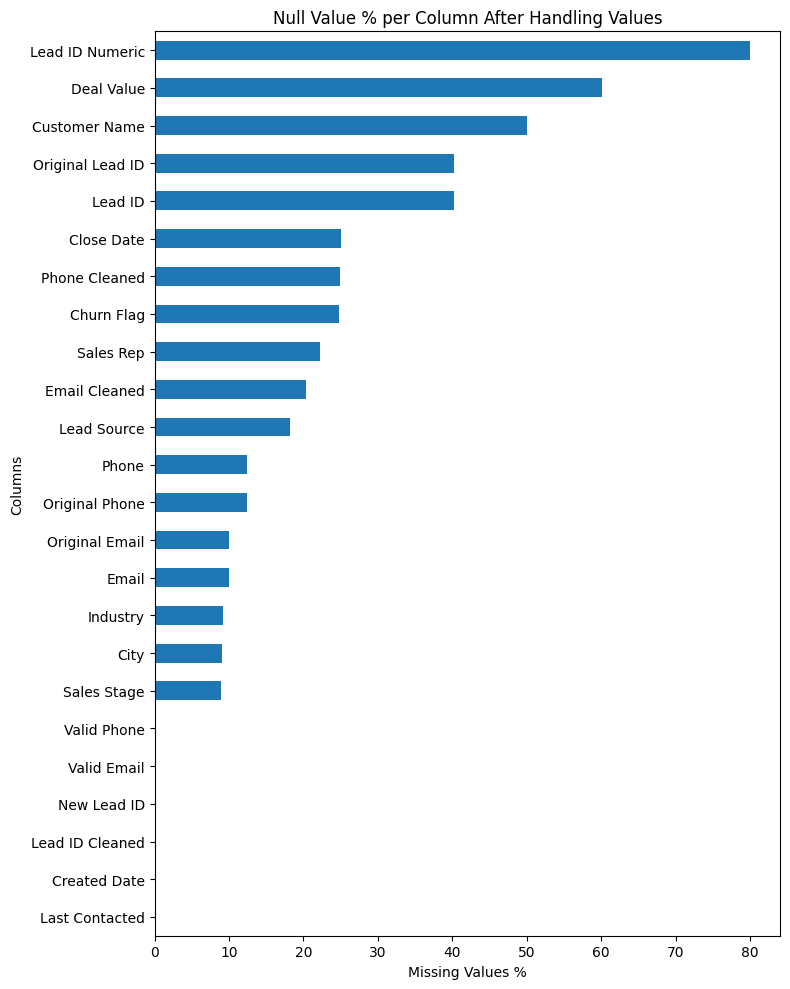

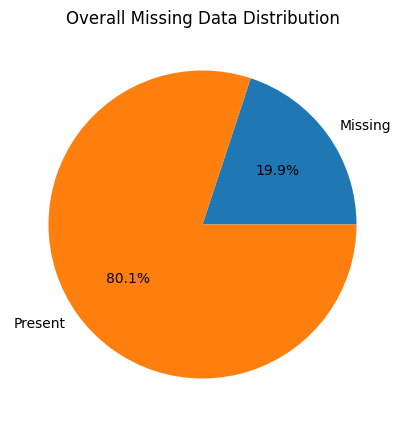

In [ ]:
# Basic Null Value Analysis After Schema Fixes & Handling Values
# Top Values per Column (Quick Profile Table)
print("\nTop Values per Column After Handling Values:")
profile = pd.DataFrame({
    'Data Type': dataset.dtypes,
    'Unique Values': dataset.nunique(),
    'Null Count': dataset.isnull().sum(),
    'Null %': (dataset.isnull().sum()/len(dataset))*100
})
print(profile)

# Single Visualization for Profiling
import matplotlib.pyplot as plt
null_percentage = (dataset.isnull().sum() / len(dataset)) * 100
null_percentage = null_percentage.sort_values(ascending=True)
plt.figure(figsize=(8,10))
null_percentage.plot(kind='barh')
plt.title("Null Value % per Column After Handling Values")
plt.xlabel("Missing Values %")
plt.ylabel("Columns")
plt.tight_layout()
plt.show()

# For Overall Missing vs Non-Missing
total_cells = dataset.size
total_missing = dataset.isnull().sum().sum()
total_present = total_cells - total_missing
plt.figure(figsize=(5,5))
plt.pie(
    [total_missing, total_present],
    labels=["Missing", "Present"],
    autopct='%1.1f%%'
)
plt.title("Overall Missing Data Distribution")
plt.show()

In [ ]:
# Advanced Data Profiling After Schema Fixes
# Unique Values Analysis
print(f"Unique Value Analysis After Schema Fixes:")
print(dataset.nunique())

# Value Distribution for Categorical Columns
print("\nValue Distribution for Categorical Columns After Schema Fixes:")
for col in dataset.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(dataset[col].value_counts())

# Numerical Column Distribution
print("\nNumerical Column Distribution After Schema Fixes:")
print(dataset.select_dtypes(include=['int64', 'float64']).describe().T)

Unique Value Analysis After Schema Fixes:
Lead ID              59756
Customer Name        50000
Email                89965
Phone                87324
Lead Source              7
Industry                 7
City                     7
Sales Stage              7
Created Date          2516
Close Date            2874
Deal Value           24247
Sales Rep                5
Last Contacted        2997
Churn Flag               2
Original Lead ID     59756
Lead ID Numeric      19965
New Lead ID         100000
Lead ID Cleaned     100000
Original Email       89965
Email Cleaned        79725
Valid Email              2
Original Phone       87324
Phone Cleaned        75036
Valid Phone              2
dtype: int64

Value Distribution for Categorical Columns After Schema Fixes:

Column: Lead ID
Lead ID
99996      1
1          1
L2         1
L4         1
Lead-5     1
          ..
Lead-25    1
Lead-22    1
21         1
Lead-19    1
18         1
Name: count, Length: 59756, dtype: int64

Column: Customer Name
C

In [ ]:
# Replace All Missing Values with NA
import pandas as pd
# Replace empty strings and space-only cells with NA
dataset = dataset.replace(r'^\s*$', pd.NA, regex=True)
# Replace text versions of null
dataset = dataset.replace(['Null', 'null', 'NA', 'NaN', 'None'], pd.NA)
dataset.head(50)

,Lead ID,Customer Name,Email,Phone,Lead Source,Industry,City,Sales Stage,Created Date,Close Date,...,Original Lead ID,Lead ID Numeric,New Lead ID,Lead ID Cleaned,Original Email,Email Cleaned,Valid Email,Original Phone,Phone Cleaned,Valid Phone
0,NaN,NaN,User0@Example,NaN,Referral,Real Estate,Bengaluru,Won,13-07-2022,16-03-2023,...,NaN,NaN,1,99997.0,User0@Example,<NA>,False,NaN,<NA>,False
1,1,NaN,User1Example.Com,7.729251e+09,Referral,Manufacturing,Delhi,Contacted,04-01-2020,26-04-2020,...,1,1.0,2,1.0,User1Example.Com,<NA>,False,7.729251e+09,7729251472,True
2,L2,NaN,User2@Example.Com,3.980060e+06,Cold Call,Real Estate,Delhi,Lost,13-06-2019,NaN,...,L2,NaN,3,99998.0,User2@Example.Com,user2@example.com,True,3.980060e+06,<NA>,False
3,NaN,NaN,User3@Example.Com,8.750642e+09,Email Campaign,Manufacturing,Mumbai,New,11-07-2019,22-08-2019,...,NaN,NaN,4,99999.0,User3@Example.Com,user3@example.com,True,8.750642e+09,8750641679,True
4,L4,NaN,User4@Example,9.969125e+09,Cold Call,Manufacturing,Bengaluru,NaN,02-05-2019,NaN,...,L4,NaN,5,100000.0,User4@Example,<NA>,False,9.969125e+09,9969124863,True
5,Lead-5,NaN,User5@Example.Com,8.295093e+09,NaN,Finance,Hyderabad,NaN,25-03-2022,16-08-2022,...,Lead-5,NaN,6,100001.0,User5@Example.Com,user5@example.com,True,8.295093e+09,8295092627,True
6,Lead-6,NaN,User6@Example.Com,NaN,NaN,Education,Hyderabad,Lost,19-10-2020,01-04-2021,...,Lead-6,NaN,7,100002.0,User6@Example.Com,user6@example.com,True,NaN,<NA>,False
7,Lead-7,NaN,User7@Example.Com,8.982157e+09,Referral,Real Estate,Pune,NaN,07-03-2020,17-04-2020,...,Lead-7,NaN,8,100003.0,User7@Example.Com,user7@example.com,True,8.982157e+09,8982156824,True
8,Lead-8,NaN,User8@Example.Com,8.195226e+09,NaN,Healthcare,Delhi,NaN,11-09-2023,19-08-2024,...,Lead-8,NaN,9,100004.0,User8@Example.Com,user8@example.com,True,8.195226e+09,8195226332,True
9,9,NaN,NaN,8.393279e+09,Walk-In,Education,Hyderabad,Won,07-05-2024,NaN,...,9,9.0,10,9.0,NaN,<NA>,False,8.393279e+09,8393279145,True


In [ ]:
# Date Fixing Created Date ≤ Last Contacted Date ≤ Close Date or Created Date ≤ Last Contacted & Close Date can be NA
import pandas as pd
# Convert to datetime FIRST
dataset['Created Date'] = pd.to_datetime(dataset['Created Date'], dayfirst=True, errors='coerce')
dataset['Last Contacted'] = pd.to_datetime(dataset['Last Contacted'], dayfirst=True, errors='coerce')
dataset['Close Date'] = pd.to_datetime(dataset['Close Date'], dayfirst=True, errors='coerce')

# Validate BEFORE Fix Rule: Created Date ≤ Last Contacted ≤ Close Date OR Close Date can be NA
dataset['Date Valid Before Fix'] = (
    (dataset['Created Date'] <= dataset['Last Contacted']) &
    (
        dataset['Close Date'].isna() |
        (dataset['Last Contacted'] <= dataset['Close Date'])
    )
)
print("Date Validation Summary (Before Fix):")
print(dataset['Date Valid Before Fix'].value_counts())

dataset['Created Date'] = dataset['Created Date'].dt.strftime('%d-%m-%Y')
dataset['Last Contacted'] = dataset['Last Contacted'].dt.strftime('%d-%m-%Y')
dataset['Close Date'] = dataset['Close Date'].dt.strftime('%d-%m-%Y')

# Store invalid indices before fix
invalid_before = dataset[dataset['Date Valid Before Fix'] == False].index
print("\nSample Invalid Records (Before Fix):")
print(dataset.loc[invalid_before,
      ['Created Date','Last Contacted','Close Date']].head(20))

dataset['Created Date'] = pd.to_datetime(dataset['Created Date'], dayfirst=True, errors='coerce')
dataset['Last Contacted'] = pd.to_datetime(dataset['Last Contacted'], dayfirst=True, errors='coerce')
dataset['Close Date'] = pd.to_datetime(dataset['Close Date'], dayfirst=True, errors='coerce')

# Fix Invalid Dates
# If Last Contacted < Created → set equal to Created
mask1 = dataset['Last Contacted'] < dataset['Created Date']
dataset.loc[mask1, 'Last Contacted'] = dataset['Created Date']
# If Close Date < Last Contacted → set equal to Last Contacted
mask2 = dataset['Close Date'] < dataset['Last Contacted']
dataset.loc[mask2, 'Close Date'] = dataset['Last Contacted']

dataset['Created Date'] = dataset['Created Date'].dt.strftime('%d-%m-%Y')
dataset['Last Contacted'] = dataset['Last Contacted'].dt.strftime('%d-%m-%Y')
dataset['Close Date'] = dataset['Close Date'].dt.strftime('%d-%m-%Y')

# Validate AFTER Fix
dataset['Date Valid After Fix'] = (
    (dataset['Created Date'] <= dataset['Last Contacted']) &
    (
        dataset['Close Date'].isna() |
        (dataset['Last Contacted'] <= dataset['Close Date'])
    )
)
print("\nDate Validation Summary (After Fix):")
print(dataset['Date Valid After Fix'].value_counts())

# Show same records after fix
print("\nSame Records After Fix:")
print(dataset.loc[invalid_before,
      ['Created Date','Last Contacted','Close Date']].head(20))

Date Validation Summary (Before Fix):
Date Valid Before Fix
False    62101
True     37899
Name: count, dtype: int64

Sample Invalid Records (Before Fix):
   Created Date Last Contacted  Close Date
1    04-01-2020     22-12-2020  26-04-2020
2    13-06-2019     18-02-2019         NaN
3    11-07-2019     04-05-2020  22-08-2019
4    02-05-2019     19-02-2019         NaN
5    25-03-2022     13-03-2022  16-08-2022
6    19-10-2020     06-04-2021  01-04-2021
7    07-03-2020     04-04-2021  17-04-2020
10   20-04-2024     10-05-2025  21-05-2024
13   02-10-2023     01-11-2023  27-10-2023
15   13-10-2019     20-07-2019         NaN
17   18-01-2018     08-03-2018  03-12-2017
21   28-01-2023     29-10-2022         NaN
22   28-06-2020     27-06-2020  07-09-2020
23   21-09-2018     11-06-2018  12-11-2018
24   14-12-2022     03-10-2022  28-03-2023
26   27-12-2019     02-10-2020  20-12-2019
27   14-09-2024     28-07-2024  29-03-2025
28   16-08-2019     21-12-2019  06-12-2019
29   15-04-2019     28-01-201

In [ ]:
dataset.head(50)

,Lead ID,Customer Name,Email,Phone,Lead Source,Industry,City,Sales Stage,Created Date,Close Date,...,New Lead ID,Lead ID Cleaned,Original Email,Email Cleaned,Valid Email,Original Phone,Phone Cleaned,Valid Phone,Date Valid Before Fix,Date Valid After Fix
0,NaN,NaN,User0@Example,NaN,Referral,Real Estate,Bengaluru,Won,13-07-2022,16-03-2023,...,1,99997.0,User0@Example,<NA>,False,NaN,<NA>,False,True,False
1,1,NaN,User1Example.Com,7.729251e+09,Referral,Manufacturing,Delhi,Contacted,04-01-2020,22-12-2020,...,2,1.0,User1Example.Com,<NA>,False,7.729251e+09,7729251472,True,False,True
2,L2,NaN,User2@Example.Com,3.980060e+06,Cold Call,Real Estate,Delhi,Lost,13-06-2019,NaN,...,3,99998.0,User2@Example.Com,user2@example.com,True,3.980060e+06,<NA>,False,False,True
3,NaN,NaN,User3@Example.Com,8.750642e+09,Email Campaign,Manufacturing,Mumbai,New,11-07-2019,04-05-2020,...,4,99999.0,User3@Example.Com,user3@example.com,True,8.750642e+09,8750641679,True,False,False
4,L4,NaN,User4@Example,9.969125e+09,Cold Call,Manufacturing,Bengaluru,NaN,02-05-2019,NaN,...,5,100000.0,User4@Example,<NA>,False,9.969125e+09,9969124863,True,False,True
5,Lead-5,NaN,User5@Example.Com,8.295093e+09,NaN,Finance,Hyderabad,NaN,25-03-2022,16-08-2022,...,6,100001.0,User5@Example.Com,user5@example.com,True,8.295093e+09,8295092627,True,False,False
6,Lead-6,NaN,User6@Example.Com,NaN,NaN,Education,Hyderabad,Lost,19-10-2020,06-04-2021,...,7,100002.0,User6@Example.Com,user6@example.com,True,NaN,<NA>,False,False,False
7,Lead-7,NaN,User7@Example.Com,8.982157e+09,Referral,Real Estate,Pune,NaN,07-03-2020,04-04-2021,...,8,100003.0,User7@Example.Com,user7@example.com,True,8.982157e+09,8982156824,True,False,False
8,Lead-8,NaN,User8@Example.Com,8.195226e+09,NaN,Healthcare,Delhi,NaN,11-09-2023,19-08-2024,...,9,100004.0,User8@Example.Com,user8@example.com,True,8.195226e+09,8195226332,True,True,False
9,9,NaN,NaN,8.393279e+09,Walk-In,Education,Hyderabad,Won,07-05-2024,NaN,...,10,9.0,NaN,<NA>,False,8.393279e+09,8393279145,True,True,True


In [ ]:
# Handling Deal Value (Deal Value < 0)
import pandas as pd
import numpy as np
# Convert to numeric
dataset['Deal Value Cleaned'] = pd.to_numeric(
    dataset['Deal Value'],
    errors='coerce'
)

# Replace negative values with NaN
dataset.loc[
    dataset['Deal Value Cleaned'] < 0,
    'Deal Value Cleaned'
] = np.nan

# Check result
print(dataset[['Deal Value', 'Deal Value Cleaned']].head(50))

    Deal Value  Deal Value Cleaned
0     557597.0            557597.0
1          NaN                 NaN
2      39862.0             39862.0
3          NaN                 NaN
4          NaN                 NaN
5      98165.0             98165.0
6          NaN                 NaN
7      -2083.0                 NaN
8      -4138.0                 NaN
9      -2918.0                 NaN
10         NaN                 NaN
11         NaN                 NaN
12         NaN                 NaN
13         NaN                 NaN
14         NaN                 NaN
15         NaN                 NaN
16         NaN                 NaN
17         NaN                 NaN
18     -4470.0                 NaN
19     -1093.0                 NaN
20    705497.0            705497.0
21         NaN                 NaN
22    690425.0            690425.0
23     -2491.0                 NaN
24    418727.0            418727.0
25     19574.0             19574.0
26         NaN                 NaN
27         NaN      

In [ ]:
# Same Sales Rep Handling Multiple Leads
# Just Check Distribution
rep_counts = dataset['Sales Rep'].value_counts()
print("Check Sales Rep Distribution:")
print(rep_counts)

# Check Workload Imbalance
print("\nMaximum leads handled by one rep:", rep_counts.max())
print("Minimum leads handled by one rep:", rep_counts.min())

Check Sales Rep Distribution:
Sales Rep
Amit     22278
Rahul    22207
Priya    11154
Sneha    11059
Rohit    11032
Name: count, dtype: int64

Maximum leads handled by one rep: 22278
Minimum leads handled by one rep: 11032


In [ ]:
# Business Logic
# Closed Won with Negative Deal Value
won_negative_value = dataset[
    (dataset['Sales Stage'] == 'Closed Won') &
    (dataset['Deal Value Cleaned'] < 0)
]
print("Closed Won Deals with Negative Deal Value:", len(won_negative_value))

Closed Won Deals with Negative Deal Value: 0


In [ ]:
# Save preprocessed file
dataset.to_csv("Cleaned_CRM_Dataset.csv", index=False, na_rep='NA')
# Download preprocessed file
files.download("Cleaned_CRM_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Dataset Info
print("\nDataset Info:")
dataset.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Lead ID                59756 non-null   object 
 1   Customer Name          50000 non-null   object 
 2   Email                  89965 non-null   object 
 3   Phone                  87525 non-null   float64
 4   Lead Source            81877 non-null   object 
 5   Industry               90818 non-null   object 
 6   City                   90892 non-null   object 
 7   Sales Stage            91044 non-null   object 
 8   Created Date           100000 non-null  object 
 9   Close Date             74943 non-null   object 
 10  Deal Value             39866 non-null   float64
 11  Sales Rep              77730 non-null   object 
 12  Last Contacted         100000 non-null  object 
 13  Churn Flag             75181 non-null   object 
 14  Original Lead ID      